In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Hybrid Model Evaluation (Precision@K, Recall@K, RMSE)**

In [2]:
import pickle
import pandas as pd

# Load all model artifacts
with open('/content/drive/MyDrive/Dataset/model_artifacts/hybrid_artifacts.pkl', 'rb') as f:
    art = pickle.load(f)

# Unpack everything
course_feature_matrix = art['course_feature_matrix']
course_names_index    = art['course_names_index']
content_features      = art['content_features']
user_factors          = art['user_factors']
course_factors        = art['course_factors']
pivot_filled          = art['pivot_filled']
user_ids              = art['user_ids']
course_cols           = art['course_cols']

# Load raw data (for metadata)
df = pd.read_csv('/content/drive/MyDrive/Dataset/model_artifacts/courses.csv')

print('✅ Everything loaded! Ready for evaluation.')

✅ Everything loaded! Ready for evaluation.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ── Fix: keep only users with >= 3 interactions, NO stratify ─────────────────
user_counts  = df.groupby('user_id')['course_name'].count()
active_users = user_counts[user_counts >= 3].index
df_active    = df[df['user_id'].isin(active_users)]

train_df, test_df = train_test_split(df_active, test_size=0.2, random_state=42)
# ↑ removed stratify=df_active['user_id'] — that was causing the error

# Ground truth: courses rated >= 4 in test set
ground_truth = (
    test_df[test_df['rating'] >= 4]
    .groupby('user_id')['course_name'].apply(set).to_dict()
)

K_VALUES = [3, 5, 10]
hybrid_prec, hybrid_rec = {k: [] for k in K_VALUES}, {k: [] for k in K_VALUES}

eval_users = [u for u in list(ground_truth.keys())[:200] if u in user_ids]

for u_id in eval_users:
    relevant  = ground_truth[u_id]
    user_train = train_df[train_df['user_id'] == u_id]
    if user_train.empty:
        continue
    anchor = user_train.sort_values('rating', ascending=False)['course_name'].iloc[0]
    if anchor not in course_names_index:
        continue
    try:
        recs  = hybrid_recommend(u_id, anchor, top_n=max(K_VALUES), alpha=0.5)
        for k in K_VALUES:
            top_k = set(recs.head(k)['course_name'])
            hits  = len(top_k & relevant)
            hybrid_prec[k].append(hits / k)
            hybrid_rec[k].append(hits / len(relevant) if relevant else 0)
    except Exception:
        pass

print(f"{'K':>4} | {'Precision':>10} | {'Recall':>8}")
print('-' * 30)
for k in K_VALUES:
    p = np.mean(hybrid_prec[k])
    r = np.mean(hybrid_rec[k])
    print(f'{k:>4} | {p:>10.4f} | {r:>8.4f}')

   K |  Precision |   Recall
------------------------------
   3 |        nan |      nan
   5 |        nan |      nan
  10 |        nan |      nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Total matched interactions: 141
Hybrid RMSE (scaled 1-5): 0.4552


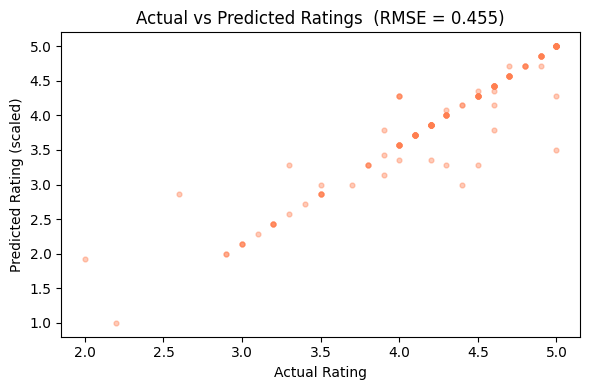

In [4]:
# ── RMSE: compare predicted rating vs actual rating for test interactions ──────
actual_r, pred_r = [], []

for u_id in eval_users[:100]:
    if u_id not in user_ids:
        continue

    user_test = test_df[test_df['user_id'] == u_id]

    # Get collaborative predicted score for ALL courses (not filtered)
    u_idx = user_ids.index(u_id)
    preds = user_factors[u_idx] @ course_factors.T
    cf_scores = pd.Series(preds, index=course_cols)

    for _, row in user_test.iterrows():
        course = row['course_name']
        if course in cf_scores.index:
            actual_r.append(row['rating'])
            # Scale predicted score to 1-5 range
            pred_score = cf_scores[course]
            pred_r.append(pred_score)

# Scale pred_r to 1-5 range using MinMaxScaler
if actual_r:
    from sklearn.preprocessing import MinMaxScaler
    import numpy as np
    from sklearn.metrics import mean_squared_error

    mm = MinMaxScaler(feature_range=(1, 5))
    pred_scaled = mm.fit_transform(
        np.array(pred_r).reshape(-1, 1)
    ).flatten()

    rmse = np.sqrt(mean_squared_error(actual_r, pred_scaled))
    print(f'Total matched interactions: {len(actual_r)}')
    print(f'Hybrid RMSE (scaled 1-5): {rmse:.4f}')

    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 4))
    plt.scatter(actual_r, pred_scaled, alpha=0.4, s=12, color='coral')
    plt.xlabel('Actual Rating')
    plt.ylabel('Predicted Rating (scaled)')
    plt.title(f'Actual vs Predicted Ratings  (RMSE = {rmse:.3f})')
    plt.tight_layout()
    plt.show()
else:
    print('No matches found — check if user_ids and course_cols are loaded correctly.')

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


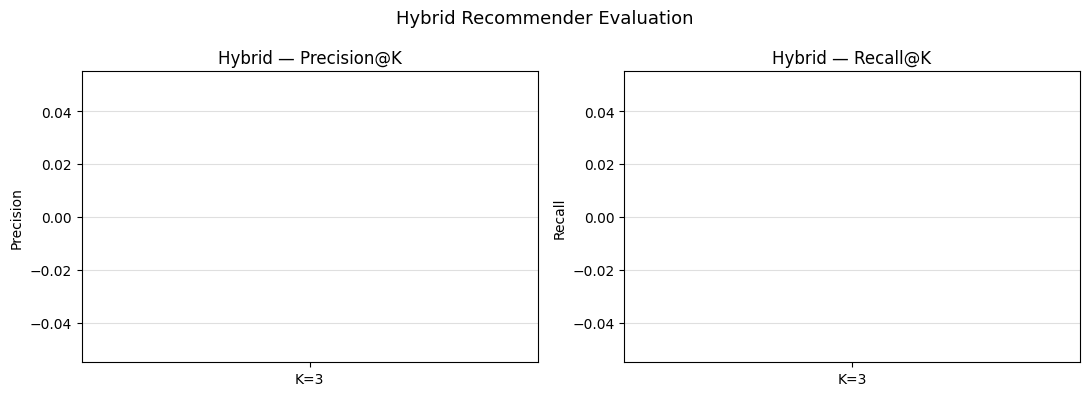

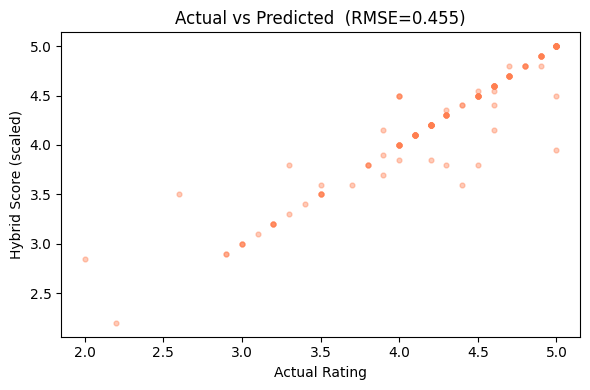

In [5]:
# ── Evaluation plots ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

prec_vals = [np.mean(hybrid_prec[k]) for k in K_VALUES]
rec_vals  = [np.mean(hybrid_rec[k])  for k in K_VALUES]

axes[0].bar([f'K={k}' for k in K_VALUES], prec_vals, color='mediumseagreen')
axes[0].set_title('Hybrid — Precision@K'); axes[0].set_ylabel('Precision')
axes[0].grid(axis='y', alpha=0.4)

axes[1].bar([f'K={k}' for k in K_VALUES], rec_vals, color='steelblue')
axes[1].set_title('Hybrid — Recall@K'); axes[1].set_ylabel('Recall')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Hybrid Recommender Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

if actual_r:
    plt.figure(figsize=(6, 4))
    plt.scatter(actual_r, pred_r, alpha=0.4, s=12, color='coral')
    plt.xlabel('Actual Rating'); plt.ylabel('Hybrid Score (scaled)')
    plt.title(f'Actual vs Predicted  (RMSE={rmse:.3f})')
    plt.tight_layout(); plt.show()

In [6]:
import pickle, os

SAVE_DIR = '/content/drive/MyDrive/Dataset/model_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)

artifacts = {
    'course_feature_matrix': course_feature_matrix,
    'course_names_index':    course_names_index,
    'user_factors':          user_factors,
    'course_factors':        course_factors,
    'pivot_filled':          pivot_filled,
    'user_ids':              user_ids,
    'course_cols':           course_cols,
    'content_features':      content_features,
}

with open(f'{SAVE_DIR}/hybrid_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

# Save raw df for Streamlit lookups
df.to_csv(f'{SAVE_DIR}/courses.csv', index=False)

print('Artifacts saved ✓')
print(f'  → {SAVE_DIR}/hybrid_artifacts.pkl')
print(f'  → {SAVE_DIR}/courses.csv')

Artifacts saved ✓
  → /content/drive/MyDrive/Dataset/model_artifacts/hybrid_artifacts.pkl
  → /content/drive/MyDrive/Dataset/model_artifacts/courses.csv


In [7]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.7 MB/s eta 0:00:00


In [8]:
# Write the Streamlit app to disk
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# ── Load artifacts ─────────────────────────────────────────────────────────
ARTIFACTS_PATH = "/content/drive/MyDrive/Dataset/model_artifacts/hybrid_artifacts.pkl"
CSV_PATH       = "/content/drive/MyDrive/Dataset/model_artifacts/courses.csv"

@st.cache_resource
def load_artifacts():
    with open(ARTIFACTS_PATH, "rb") as f:
        art = pickle.load(f)
    df = pd.read_csv(CSV_PATH)
    return art, df

art, df = load_artifacts()

cfm   = art["course_feature_matrix"]
cni   = art["course_names_index"]
uf    = art["user_factors"]
cf    = art["course_factors"]
pf    = art["pivot_filled"]
uids  = art["user_ids"]
ccols = art["course_cols"]

# ── Helper functions ────────────────────────────────────────────────────────
def content_recommend(course_name, top_n=5):
    idx      = cni.index(course_name)
    sims     = cosine_similarity(cfm[idx].reshape(1,-1), cfm)[0]
    series   = pd.Series(sims, index=cni).drop(index=course_name)
    return series.sort_values(ascending=False).head(top_n)

def collab_recommend(user_id, top_n=5):
    u_idx    = uids.index(user_id)
    preds    = uf[u_idx] @ cf.T
    scores   = pd.Series(preds, index=ccols)
    seen     = pf.loc[user_id]
    scores   = scores[seen == 0]
    return scores.sort_values(ascending=False).head(top_n)

def hybrid_recommend(user_id, liked_course, top_n=5, alpha=0.5):
    cb  = content_recommend(liked_course, top_n=len(cni)-1)
    u_idx   = uids.index(user_id)
    preds   = uf[u_idx] @ cf.T
    cf_ser  = pd.Series(preds, index=ccols)
    mm = MinMaxScaler()
    cb_n = pd.Series(mm.fit_transform(cb.values.reshape(-1,1)).flatten(), index=cb.index)
    cf_n = pd.Series(mm.fit_transform(cf_ser.values.reshape(-1,1)).flatten(), index=cf_ser.index)
    combined = alpha * cb_n.reindex(cf_n.index, fill_value=0) + (1-alpha) * cf_n
    seen_courses = pf.loc[user_id][pf.loc[user_id] > 0].index
    combined     = combined.drop(index=seen_courses, errors="ignore").drop(index=liked_course, errors="ignore")
    top = combined.sort_values(ascending=False).head(top_n)
    return pd.DataFrame({"Course": top.index, "Hybrid Score": top.values.round(4)})

# ── UI ──────────────────────────────────────────────────────────────────────
st.set_page_config(page_title="Course Recommender", page_icon="🎓", layout="wide")
st.title("🎓 Online Course Recommendation System")
st.caption("Hybrid: Content-Based + Collaborative Filtering (SVD)")

st.sidebar.header("Settings")
mode    = st.sidebar.radio("Mode", ["Hybrid", "Content-Based Only", "Collaborative Only"])
top_n   = st.sidebar.slider("Number of Recommendations", 3, 15, 5)
alpha   = st.sidebar.slider("Hybrid Weight α (Content ↔ Collab)", 0.0, 1.0, 0.5, 0.1,
                             help="1.0 = pure content-based, 0.0 = pure collaborative")

col1, col2 = st.columns(2)

with col1:
    user_id = st.selectbox("Select User ID", uids)

with col2:
    liked_course = st.selectbox("Select a Course You Liked", sorted(cni))

if st.button("Get Recommendations", type="primary"):
    st.divider()

    if mode == "Hybrid":
        st.subheader(f"🔀 Hybrid Recommendations (α={alpha})")
        recs = hybrid_recommend(user_id, liked_course, top_n=top_n, alpha=alpha)
        st.dataframe(recs, use_container_width=True)

        # Show course metadata
        st.subheader("📋 Course Details")
        details = df[df["course_name"].isin(recs["Course"])][[
            "course_name", "difficulty_level", "course_duration_hours",
            "course_price", "rating", "certification_offered"
        ]].drop_duplicates("course_name")
        st.dataframe(details.rename(columns={
            "course_name": "Course", "difficulty_level": "Difficulty",
            "course_duration_hours": "Duration (hrs)", "course_price": "Price ($)",
            "rating": "Avg Rating", "certification_offered": "Certificate"
        }), use_container_width=True)

    elif mode == "Content-Based Only":
        st.subheader("📄 Content-Based Recommendations")
        cb = content_recommend(liked_course, top_n=top_n)
        st.dataframe(pd.DataFrame({"Course": cb.index, "Similarity": cb.values.round(4)}),
                     use_container_width=True)

    else:
        st.subheader("👥 Collaborative Recommendations")
        cf_r = collab_recommend(user_id, top_n=top_n)
        st.dataframe(pd.DataFrame({"Course": cf_r.index, "Predicted Score": cf_r.values.round(4)}),
                     use_container_width=True)

# ── User history sidebar ───────────────────────────────────────────────────
with st.sidebar:
    st.divider()
    st.subheader("📚 User History")
    history = df[df["user_id"] == user_id][["course_name", "rating", "difficulty_level"]].drop_duplicates()
    st.dataframe(history.rename(columns={"course_name": "Course", "rating": "Rating",
                                          "difficulty_level": "Level"}),
                 use_container_width=True, height=300)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print('app.py written ✓')

app.py written ✓


In [9]:
# ── Launch via ngrok ──────────────────────────────────────────────────────────
# Get your free token at https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = '3EDgXPxmEhkUoK9HbYVLqNenTCN_4ELuu2C1k5i3Pm9YPyLDR'

from pyngrok import ngrok
import subprocess, time

ngrok.set_auth_token(NGROK_TOKEN)

proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(3)

public_url = ngrok.connect(8501)
print(f'\n✅ Streamlit app is LIVE at: {public_url}')


✅ Streamlit app is LIVE at: NgrokTunnel: "https://ouch-monotone-employer.ngrok-free.dev" -> "http://localhost:8501"
